# 🤖 Pertemuan 9 — Python ML: Klasifikasi dengan scikit-learn
### Mata Kuliah: Python Machine Learning

---

## Tujuan Pembelajaran

Setelah pertemuan ini, kamu bisa:
1. Menjelaskan konsep klasifikasi dan kapan algoritma ini digunakan
2. Mengimplementasikan Logistic Regression, Decision Tree, dan Random Forest dengan scikit-learn
3. Membaca dan menginterpretasikan Confusion Matrix
4. Menghitung dan memahami Accuracy, Precision, Recall, dan F1-Score
5. Membandingkan hasil scikit-learn dengan workflow Orange yang sudah dibuat sebelumnya

---

## Recap Cepat — Quiz Kilat ⚡

Sebelum mulai, jawab pertanyaan berikut tanpa melihat catatan:

1. Apa perbedaan antara **Label Encoding** dan **One-Hot Encoding**? Kapan masing-masing digunakan?
2. Mengapa scaler harus di-`fit` hanya pada **training data**, bukan seluruh dataset?
3. Apa itu **data leakage**? Berikan contohnya.

---

In [1]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, roc_auc_score
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print("✅ Setup selesai!")

✅ Setup selesai!


---

## BAGIAN 1: Apa itu Klasifikasi?

**Klasifikasi** adalah tugas ML di mana model belajar memetakan input (fitur) ke **kategori** (label diskrit).

```
Input (fitur)          Output (prediksi)
─────────────────────────────────────────
Usia=22, Sex=male  →   Tidak Selamat (0)
Usia=35, Sex=female →  Selamat (1)
```

**Kapan menggunakan klasifikasi?**

| Pertanyaan | Jawaban | Jenis |
|-----------|---------|-------|
| Apakah email ini spam? | Ya / Tidak | Binary |
| Apakah penumpang selamat? | Ya / Tidak | Binary |
| Gambar ini kucing, anjing, atau burung? | Salah satu dari 3 | Multiclass |
| Jenis penyakit pasien? | Salah satu dari N | Multiclass |

```
> Regresi memprediksi angka kontinu (harga rumah, suhu), sedangkan klasifikasi memprediksi kategori.
```

---

## BAGIAN 2: Load Data

Kita akan menggunakan dataset **Titanic** — dataset yang sama yang sudah kamu eksplorasi di Orange (Pertemuan 2) dan dibersihkan di Pertemuan 6–7.

In [2]:
# Load data — coba dari file hasil Pertemuan 7, fallback ke seaborn
try:
    X_train = pd.read_csv('X_train.csv')
    X_test  = pd.read_csv('X_test.csv')
    y_train = pd.read_csv('y_train.csv').squeeze()
    y_test  = pd.read_csv('y_test.csv').squeeze()
    print("✅ Data dari Pertemuan 7 berhasil dimuat!")
except FileNotFoundError:
    print("⚠️ File Pertemuan 7 tidak ditemukan — membangun ulang pipeline...")
    df = sns.load_dataset('titanic')
    df = df.drop(columns=['deck'])
    df['age']        = df['age'].fillna(df['age'].median())
    df['embarked']   = df['embarked'].fillna(df['embarked'].mode()[0])
    df['embark_town']= df['embark_town'].fillna(df['embark_town'].mode()[0])

    kolom_buang = ['alive', 'who', 'adult_male', 'embark_town', 'alone']
    df = df.drop(columns=kolom_buang)

    le = LabelEncoder()
    df['sex_encoded']   = le.fit_transform(df['sex'])
    embarked_dummies    = pd.get_dummies(df['embarked'], prefix='embarked', drop_first=True)
    class_mapping       = {'First': 1, 'Second': 2, 'Third': 3}
    df['class_encoded'] = df['class'].map(class_mapping)
    df = pd.concat([df, embarked_dummies], axis=1)
    df = df.drop(columns=['sex', 'embarked', 'class', 'pclass'])
    df = df.select_dtypes(include=[np.number]).dropna()

    X = df.drop(columns=['survived'])
    y = df['survived']
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns)
    X_test  = pd.DataFrame(scaler.transform(X_test_raw),      columns=X.columns)
    print("✅ Pipeline selesai dibangun ulang.")

print(f"\nX_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")
print(f"\nFitur yang digunakan: {X_train.columns.tolist()}")

⚠️ File Pertemuan 7 tidak ditemukan — membangun ulang pipeline...
✅ Pipeline selesai dibangun ulang.

X_train: (712, 5) | X_test: (179, 5)
y_train: (712,) | y_test: (179,)

Fitur yang digunakan: ['age', 'sibsp', 'parch', 'fare', 'sex_encoded']


---

## BAGIAN 3: Model
### Logistic Regression

**Logistic Regression** adalah algoritma klasifikasi paling sederhana dan sering dijadikan *baseline*.

Meskipun namanya "regression", ini adalah algoritma **klasifikasi** — ia memprediksi **probabilitas** suatu kelas.

```
Cara kerjanya (intuitif):

  1. Hitung skor = w₁×age + w₂×sex + w₃×fare + ...
  2. Ubah skor → probabilitas menggunakan fungsi sigmoid: P = 1 / (1 + e^(-skor))
  3. Jika P > 0.5 → prediksi kelas 1 (Selamat)
     Jika P ≤ 0.5 → prediksi kelas 0 (Tidak Selamat)
```

**Kapan cocok?**  
- Data yang relatif linear
- Butuh interpretasi (bisa lihat bobot fitur)
- Baseline sebelum mencoba model yang lebih kompleks

In [3]:
# Latih Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [4]:
y_pred_lr = lr.predict(X_test)

print("=" * 45)
print("LOGISTIC REGRESSION")
print("=" * 45)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_lr):.4f}")

LOGISTIC REGRESSION
Accuracy  : 0.7933
Precision : 0.7667
Recall    : 0.6667
F1-Score  : 0.7132


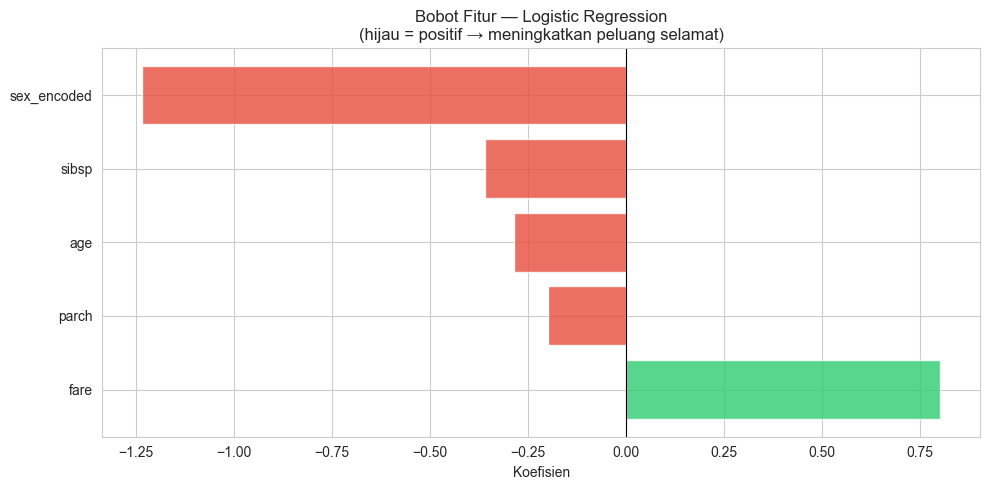


Interpretasi: Fitur dengan bobot positif meningkatkan peluang selamat (kelas 1).


In [5]:
# Lihat bobot (koefisien) setiap fitur
koefisien = pd.DataFrame({
    'Fitur'  : X_train.columns,
    'Bobot'  : lr.coef_[0]
}).sort_values('Bobot', ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in koefisien['Bobot']]
plt.barh(koefisien['Fitur'], koefisien['Bobot'], color=colors, alpha=0.8, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Bobot Fitur — Logistic Regression\n(hijau = positif → meningkatkan peluang selamat)', fontsize=12)
plt.xlabel('Koefisien')
plt.tight_layout()
plt.show()

print("\nInterpretasi: Fitur dengan bobot positif meningkatkan peluang selamat (kelas 1).")

---

#### Parameter Sensitivity pada Logistic Regression

Setiap algoritma punya **hyperparameter**. Pada Logistic Regression, parameter terpenting adalah `C` — **inverse regularization strength**.

```
C besar (100)  → regularization lemah → model lebih kompleks (bisa overfit)
C kecil (0.01) → regularization kuat  → model lebih sederhana (bisa underfit)
C = 1          → default scikit-learn
```

Mari kita lihat bagaimana nilai C yang berbeda mempengaruhi akurasi:

In [6]:
# Eksperimen: Pengaruh nilai C terhadap akurasi Logistic Regression
c_values = [0.01, 1, 100]

print("=" * 45)
print("Logistic Regression — Efek Regularization (C)")
print("=" * 45)

for c in c_values:
    lr_c = LogisticRegression(C=c, random_state=42, max_iter=1000)
    lr_c.fit(X_train, y_train)
    y_pred_c = lr_c.predict(X_test)
    acc = accuracy_score(y_test, y_pred_c)
    print(f"  C={c:<6} \u2192 Accuracy: {acc:.4f}")

print("\n\U0001f4a1 Makin kecil C, makin kuat regularization \u2014 model jadi lebih sederhana.")
print("   Pilih C yang memberi accuracy terbaik di test set (bukan train set!).")

Logistic Regression — Efek Regularization (C)
  C=0.01   → Accuracy: 0.7821
  C=1      → Accuracy: 0.7933
  C=100    → Accuracy: 0.7933

💡 Makin kecil C, makin kuat regularization — model jadi lebih sederhana.
   Pilih C yang memberi accuracy terbaik di test set (bukan train set!).


---

### Decision Tree

**Decision Tree** membuat keputusan seperti diagram alir — membagi data berdasarkan pertanyaan ya/tidak secara berulang.

```
                  [Apakah sex = female?]
                    /               \
                 Ya                  Tidak
           [fare > 10?]          [age < 10?]
           /        \              /       \
       Selamat  Tidak selamat  Selamat  Tidak selamat
```

**Kelebihan:**
- Mudah divisualisasikan dan diinterpretasikan
- Tidak butuh scaling
- Bisa menangkap hubungan non-linear

**Kekurangan:**
- Mudah **overfit** jika pohon terlalu dalam
- Tidak stabil — data sedikit berubah bisa menghasilkan pohon yang sangat berbeda

In [13]:
# Latih Decision Tree
dt = DecisionTreeClassifier(max_depth=15, random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [14]:
y_pred_dt = dt.predict(X_test)

print("=" * 45)
print("DECISION TREE (max_depth=15)")
print("=" * 45)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_dt):.4f}")

DECISION TREE (max_depth=15)
Accuracy  : 0.7877
Precision : 0.7246
Recall    : 0.7246
F1-Score  : 0.7246


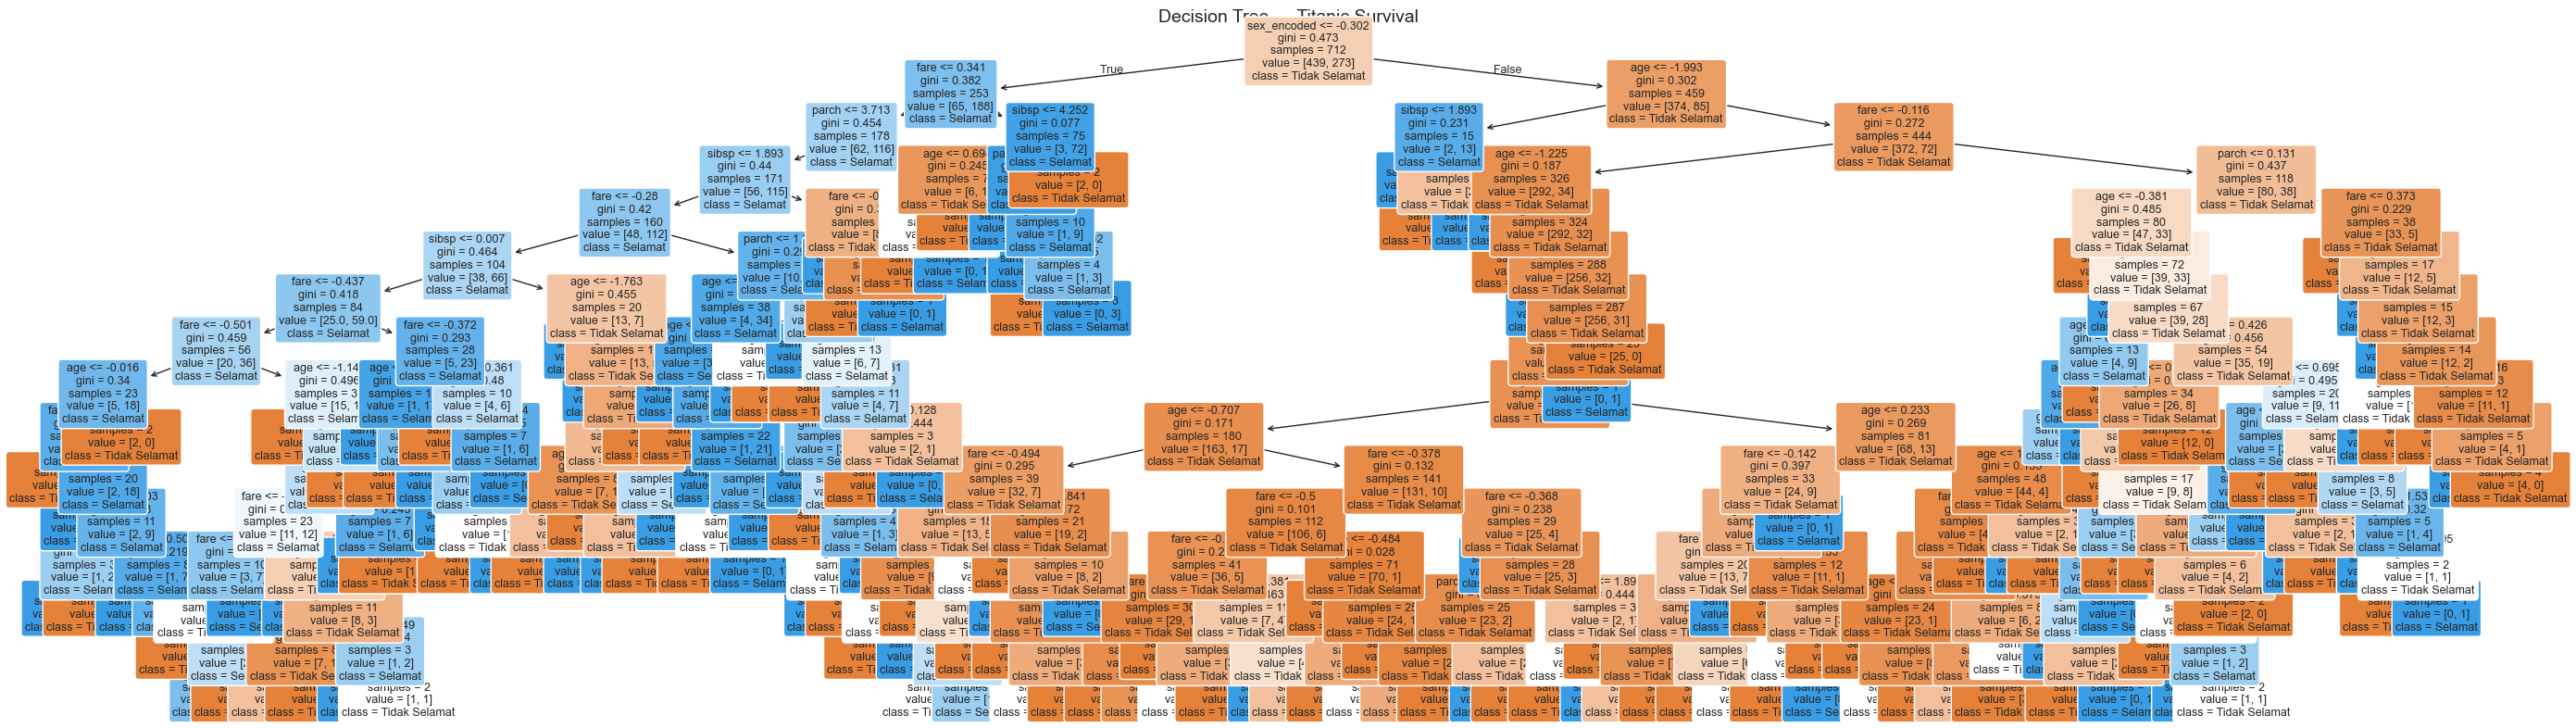

In [15]:
# Visualisasi pohon keputusan
plt.figure(figsize=(28, 8))
plot_tree(
    dt,
    feature_names=X_train.columns.tolist(),
    class_names=['Tidak Selamat', 'Selamat'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree — Titanic Survival', fontsize=14)
plt.tight_layout()
plt.show()

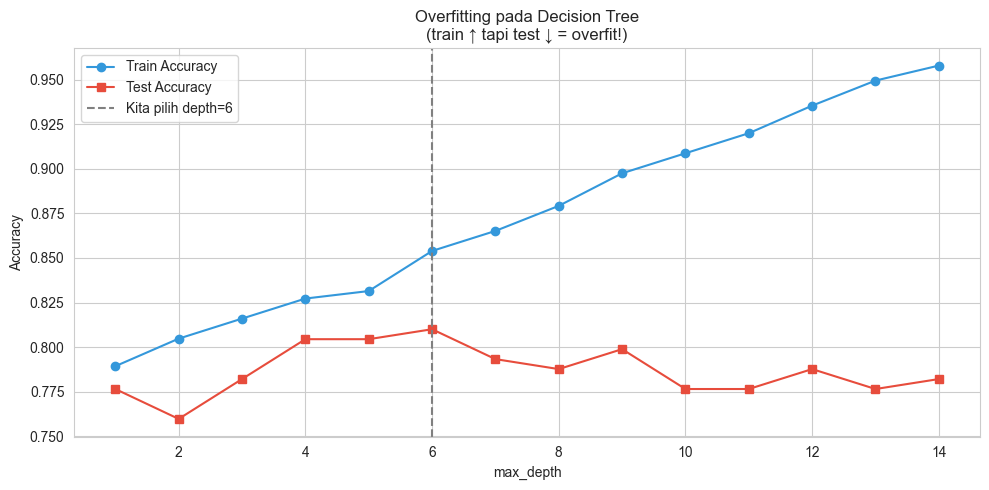


💡 Insight: Pohon yang terlalu dalam 'hafal' data training tapi gagal di data baru.


In [16]:
# Efek kedalaman pohon terhadap akurasi (overfitting demo)
depths    = range(1, 15)
train_acc = []
test_acc  = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc.append(accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_acc, 'o-', label='Train Accuracy', color='#3498db')
plt.plot(depths, test_acc,  's-', label='Test Accuracy',  color='#e74c3c')
plt.axvline(6, color='gray', linestyle='--', label='Kita pilih depth=6')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Overfitting pada Decision Tree\n(train ↑ tapi test ↓ = overfit!)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print("\n💡 Insight: Pohon yang terlalu dalam 'hafal' data training tapi gagal di data baru.")

---

### Random Forest

**Random Forest** adalah kumpulan banyak Decision Tree yang bekerja bersama (**ensemble**).

```
                    DATA TRAINING
                        │
          ┌─────────────┼─────────────┐
          │             │             │
       Tree 1        Tree 2  ...   Tree N
          │             │             │
       pred_1        pred_2        pred_N
          │             │             │
          └─────────────┼─────────────┘
                   VOTING MAJORITY
                        │
                  PREDIKSI FINAL
```

**Kelebihan:**
- Lebih tahan terhadap overfitting dibanding satu Decision Tree
- Akurasi biasanya lebih tinggi
- Memberikan **feature importance** secara alami

**Kekurangan:**
- Lebih lambat dan butuh lebih banyak memori
- Lebih sulit diinterpretasikan ("black box")

In [19]:
# Latih Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [22]:
y_pred_rf = rf.predict(X_test)

print("=" * 45)
print("RANDOM FOREST (200 trees, max_depth=6)")
print("=" * 45)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_rf):.4f}")

RANDOM FOREST (200 trees, max_depth=6)
Accuracy  : 0.8101
Precision : 0.7966
Recall    : 0.6812
F1-Score  : 0.7344


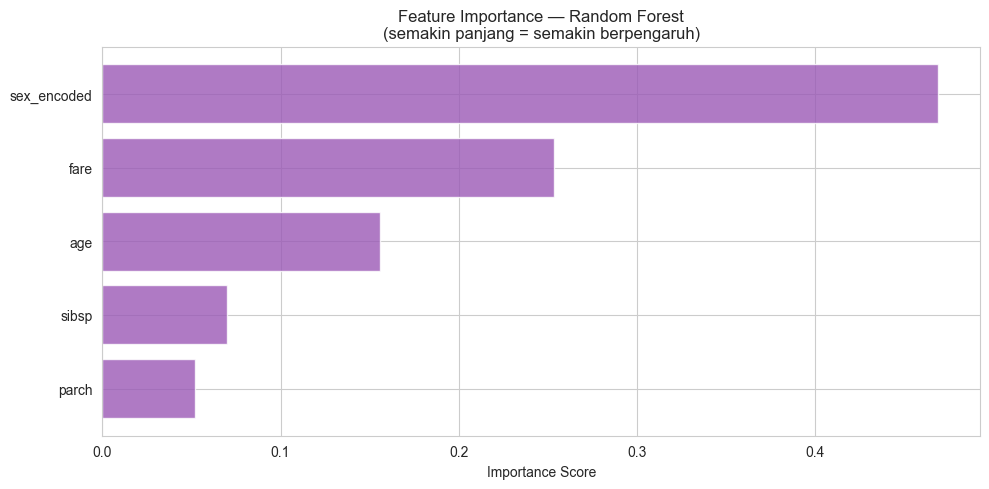

In [23]:
# Feature Importance dari Random Forest
importances = pd.DataFrame({
    'Fitur'      : X_train.columns,
    'Importance' : rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(importances['Fitur'], importances['Importance'],
         color='#9b59b6', alpha=0.8, edgecolor='white')
plt.title('Feature Importance — Random Forest\n(semakin panjang = semakin berpengaruh)', fontsize=12)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---

## BAGIAN 4:Evaluasi Model

---

### Confusion Matrix & Metrik Evaluasi

**Accuracy saja tidak cukup.** Bayangkan model yang selalu memprediksi "Tidak Selamat" — accuracy-nya bisa 60%+ tapi tidak berguna!

**Confusion Matrix** menunjukkan detail di mana model benar dan salah:

```
                    Prediksi
                 0          1
Aktual  0   [  TN  ]   [  FP  ]   → "Specificity"
        1   [  FN  ]   [  TP  ]   → "Recall / Sensitivity"
                              ↑
                          "Precision"

TN = True Negative  (prediksi 0, aktual 0 ✅)
TP = True Positive  (prediksi 1, aktual 1 ✅)
FP = False Positive (prediksi 1, aktual 0 ❌) → "Type I Error"
FN = False Negative (prediksi 0, aktual 1 ❌) → "Type II Error"
```

| Metrik | Rumus | Pertanyaannya |
|--------|-------|---------------|
| **Accuracy** | (TP+TN) / Total | Seberapa sering model benar secara keseluruhan? |
| **Precision** | TP / (TP+FP) | Dari yang diprediksi positif, berapa yang benar-benar positif? |
| **Recall** | TP / (TP+FN) | Dari yang aktual positif, berapa yang berhasil ditemukan? |
| **F1-Score** | 2 × (P×R)/(P+R) | Rata-rata harmonis Precision dan Recall |

> **Kapan Precision vs Recall lebih penting?**  
> - Deteksi kanker → **Recall** (lebih baik salah tangkap daripada melewatkan kasus)  
> - Filter spam → **Precision** (lebih baik melewatkan spam daripada hapus email penting)

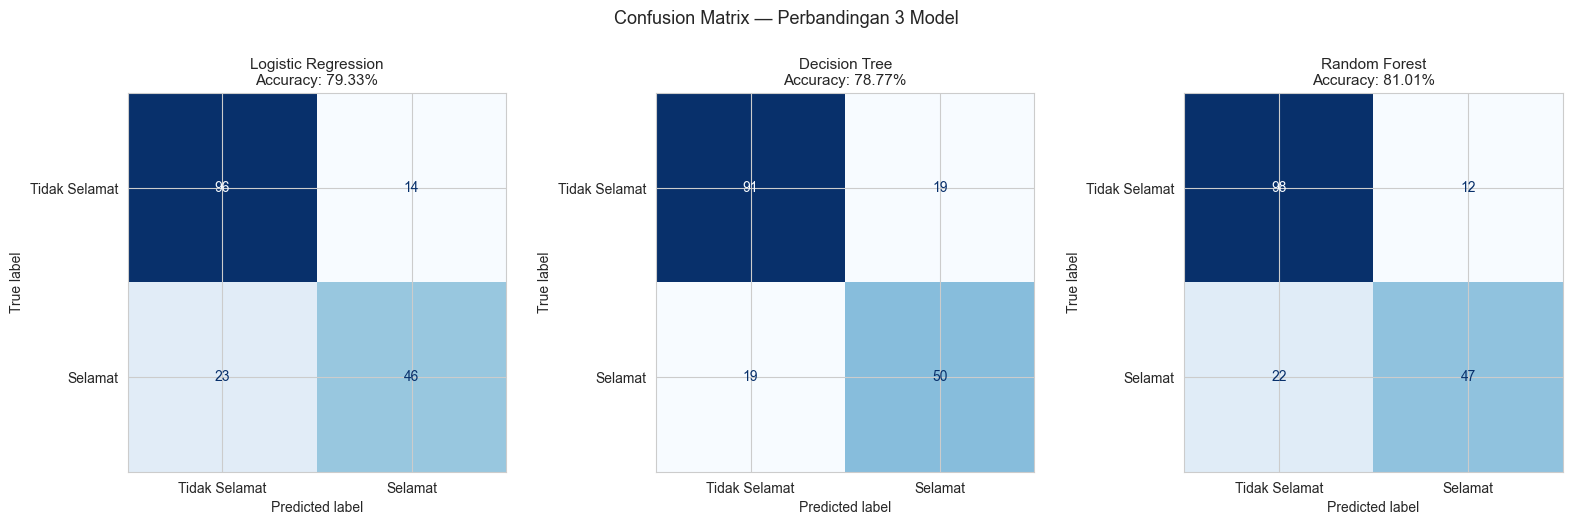

In [24]:
# Visualisasi Confusion Matrix untuk ketiga model
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_cm = [
    (y_pred_lr, 'Logistic Regression', '#3498db'),
    (y_pred_dt, 'Decision Tree',       '#e67e22'),
    (y_pred_rf, 'Random Forest',       '#9b59b6'),
]

for ax, (y_pred, nama, warna) in zip(axes, models_cm):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Tidak Selamat', 'Selamat'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nama}\nAccuracy: {accuracy_score(y_test, y_pred):.2%}', fontsize=11)

plt.suptitle('Confusion Matrix — Perbandingan 3 Model', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Classification Report lengkap
print("=" * 50)
print("CLASSIFICATION REPORT — RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, y_pred_rf,
                             target_names=['Tidak Selamat', 'Selamat']))

print("\n📌 Catatan:")
print("  support = jumlah sampel aktual per kelas di test set")
print("  macro avg = rata-rata biasa tiap metrik")
print("  weighted avg = rata-rata tertimbang berdasarkan support")

CLASSIFICATION REPORT — RANDOM FOREST
               precision    recall  f1-score   support

Tidak Selamat       0.82      0.89      0.85       110
      Selamat       0.80      0.68      0.73        69

     accuracy                           0.81       179
    macro avg       0.81      0.79      0.79       179
 weighted avg       0.81      0.81      0.81       179


📌 Catatan:
  support = jumlah sampel aktual per kelas di test set
  macro avg = rata-rata biasa tiap metrik
  weighted avg = rata-rata tertimbang berdasarkan support


---

### ROC Curve & AUC

Selain Confusion Matrix, kita juga bisa mengevaluasi model menggunakan **ROC Curve**.

ROC Curve memplot:
- Sumbu X: **False Positive Rate (FPR)** = FP / (FP + TN)
- Sumbu Y: **True Positive Rate (TPR)** = TP / (TP + FN) = Recall

Setiap titik pada kurva mewakili **threshold** yang berbeda.
AUC (*Area Under the Curve*) = 1 berarti model sempurna, AUC = 0.5 berarti acak (garis diagonal).

```
   TPR (Recall)  ↑
   1.0 ────────● Model sempurna (AUC = 1)
       ╱        │
      ╱         │
     ╱  ROC     │     ─ ─ ─ Random (AUC = 0.5)
    ╱           │
   ╱            │
  0.0 ──────────┴──→ FPR
                1.0
```

Makin dekat kurva ke pojok kiri atas → makin baik modelnya.

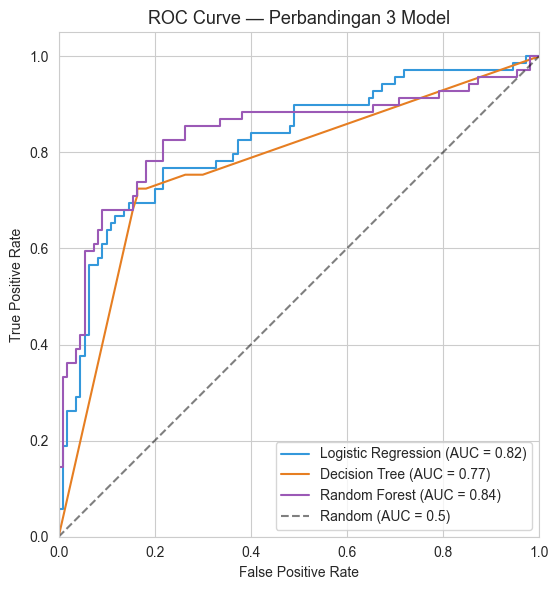

💡 AUC digunakan sebagai metrik ringkasan: makin mendekati 1 = makin baik.
   AUC 0.5 = random guessing, AUC < 0.5 = lebih buruk dari random.


In [26]:
# Plot ROC Curve untuk ketiga model
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))

models_roc = [
    (lr, 'Logistic Regression', '#3498db'),
    (dt, 'Decision Tree',       '#e67e22'),
    (rf, 'Random Forest',       '#9b59b6'),
]

try:
    for model, nama, warna in models_roc:
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=plt.gca(),
                                        name=nama, color=warna)
except NameError:
    # Fallback untuk sklearn < 1.0
    for model, nama, warna in models_roc:
        y_score = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=warna, label=f'{nama} (AUC = {roc_auc:.3f})')
    print("\u26a0️ RocCurveDisplay tidak tersedia \u2014 menggunakan fallback manual.")
    print("   Upgrade sklearn ke >= 1.0 untuk visualisasi yang lebih rapi.")

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve \u2014 Perbandingan 3 Model', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\U0001f4a1 AUC digunakan sebagai metrik ringkasan: makin mendekati 1 = makin baik.")
print("   AUC 0.5 = random guessing, AUC < 0.5 = lebih buruk dari random.")

              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.7933     0.7667  0.6667    0.7132
      Decision Tree    0.7877     0.7246  0.7246    0.7246
      Random Forest    0.8101     0.7966  0.6812    0.7344


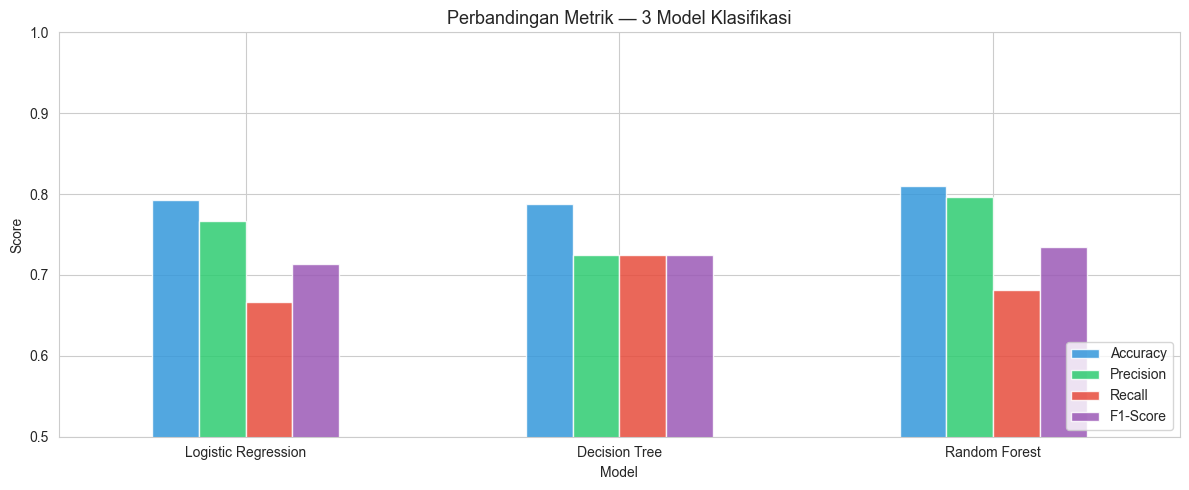

In [27]:
# Tabel perbandingan semua metrik
hasil = []
for nama, y_pred in [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree',       y_pred_dt),
    ('Random Forest',       y_pred_rf),
]:
    hasil.append({
        'Model'    : nama,
        'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred),    4),
        'F1-Score' : round(f1_score(y_test, y_pred),        4),
    })

df_hasil = pd.DataFrame(hasil)
print(df_hasil.to_string(index=False))

# Visualisasi
df_plot = df_hasil.set_index('Model')
df_plot.plot(kind='bar', figsize=(12, 5), alpha=0.85, edgecolor='white',
             color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
plt.title('Perbandingan Metrik — 3 Model Klasifikasi', fontsize=13)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---

### Cross-Validation: Evaluasi yang Lebih Robust

Sejauh ini kita hanya menggunakan **satu** train-test split. Masalahnya: hasil bisa berbeda kalau split-nya diubah.

**Cross-Validation (CV)** membagi data menjadi $k$ lipatan. Model dilatih $k$ kali, setiap kali menggunakan $k-1$ lipatan sebagai training dan 1 lipatan sebagai validasi. Hasil akhir adalah **rata-rata dari $k$ percobaan**.

```
     Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
     +------+------+------+------+------+
     | Val  | Train| Train| Train| Train|  -> skor 1
     +------+------+------+------+------+
     |Train | Val  | Train| Train| Train|  -> skor 2
     +------+------+------+------+------+
     |Train |Train | Val  | Train| Train|  -> skor 3
     +------+------+------+------+------+
     |Train |Train |Train | Val  | Train|  -> skor 4
     +------+------+------+------+------+
     |Train |Train |Train |Train | Val  |  -> skor 5
     +------+------+------+------+------+
               Hasil = rata-rata +/- std
```

Dengan CV, kita mendapat gambaran yang lebih akurat tentang performa model.

In [28]:
# Cross-Validation dengan 5-fold untuk semua model

models_cv = [
    ('Logistic Regression', LogisticRegression(random_state=42, max_iter=1000)),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=6, random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=50, max_depth=6, random_state=42)),
]

print("=" * 55)
print("CROSS-VALIDATION (5-fold) \u2014 Accuracy")
print("=" * 55)

for nama, model in models_cv:
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"  {nama:<22} \u2192 {scores.mean():.4f} +/- {scores.std():.4f}")

print("\n\U0001f4a1 Bandingkan dengan hasil train-test split sebelumnya.")
print("   CV memberikan estimasi yang lebih stabil karena diuji 5 kali.")

CROSS-VALIDATION (5-fold) — Accuracy
  Logistic Regression    → 0.7880 +/- 0.0200
  Decision Tree          → 0.7893 +/- 0.0263
  Random Forest          → 0.8133 +/- 0.0216

💡 Bandingkan dengan hasil train-test split sebelumnya.
   CV memberikan estimasi yang lebih stabil karena diuji 5 kali.


---

## ✏️ Latihan Mandiri

Kerjakan soal berikut menggunakan **dataset tim kamu sendiri** (bukan Titanic):

In [ ]:
# LATIHAN 1: Ganti dengan dataset timmu
# 1. Load dataset tim kamu (pastikan sudah di-clean dan di-prepare)
# 2. Lakukan train-test split (80:20, stratify=y)
# 3. Latih ketiga model: Logistic Regression, Decision Tree, Random Forest
# 4. Cetak Accuracy, Precision, Recall, F1 untuk setiap model

# Tulis kode di sini:


In [ ]:
# LATIHAN 2: Hyperparameter tuning Decision Tree
# Coba variasikan max_depth dari 1 sampai 20
# Plot train accuracy vs test accuracy
# Tentukan max_depth terbaik dan jelaskan alasannya

# Tulis kode di sini:


In [ ]:
# LATIHAN 3 (Tantangan): Bandingkan dengan Orange
# 1. Buka Orange, buat workflow dengan dataset timmu
# 2. Gunakan Test and Score untuk mendapatkan metrik
# 3. Masukkan hasil Orange ke tabel perbandingan
# 4. Tulis 2-3 kalimat analisis: apakah hasilnya konsisten? mengapa?

# Tulis kode dan analisis di sini:


---

## 📝 Ringkasan Pertemuan 9

```
KLASIFIKASI — ALUR LENGKAP

DATA SIAP ML (dari P7)
    ↓
[P9] Pilih Algoritma Klasifikasi
        ├── Logistic Regression  → simple, interpretable, baseline
        ├── Decision Tree        → visual, non-linear, mudah overfit
        └── Random Forest        → ensemble, robust, feature importance
    ↓
[P9] model.fit(X_train, y_train)
    ↓
[P9] y_pred = model.predict(X_test)
    ↓
[P9] Evaluasi
        ├── Accuracy   → overall correctness
        ├── Precision  → quality of positive predictions
        ├── Recall     → coverage of actual positives
        ├── F1-Score   → balance of Precision & Recall
        └── Confusion Matrix → detail per kelas
```

---

**Pertemuan berikutnya: Python ML — Regresi** 📈  
Dari prediksi kategori → prediksi nilai kontinu (harga, suhu, pendapatan)